In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.shape

(32581, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
df['loan_status'].unique()


array([1, 0])

In [8]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

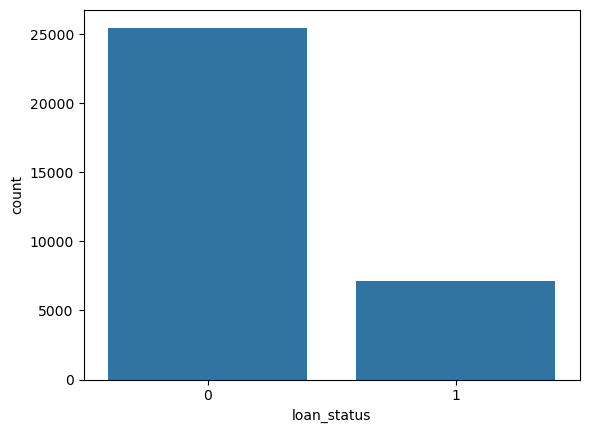

In [9]:
#This graphs shows the class imbalance
sns.countplot(x = 'loan_status', data =df)

In [10]:
#checking the outliers
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [11]:
#to check outliers we see boxplot
#first we extracted numerical columns from dataset to make box plot
numerical_cols = df.select_dtypes(include = np.number).columns

In [12]:
numerical_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

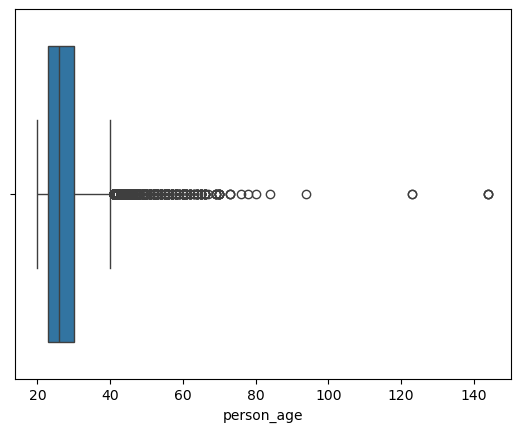

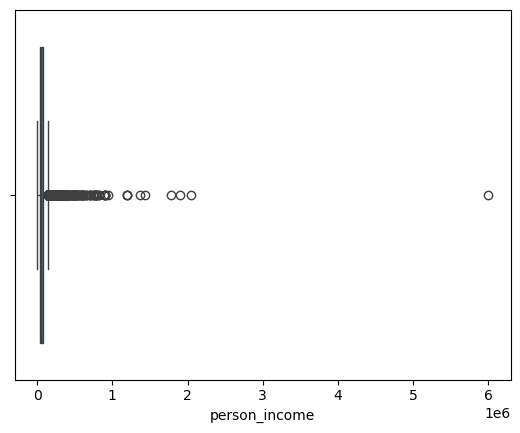

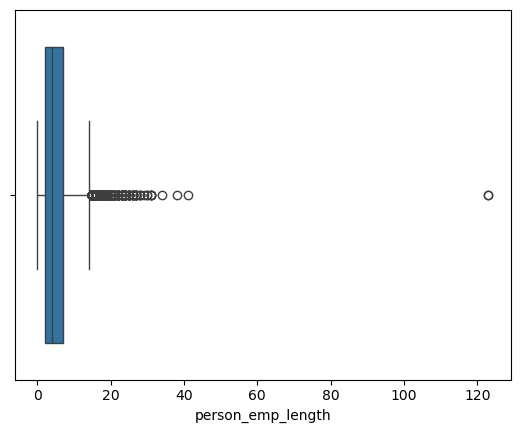

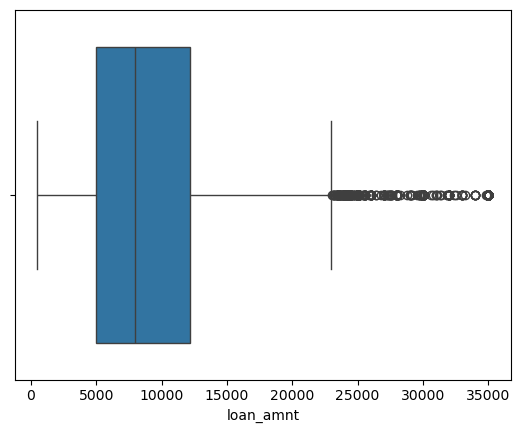

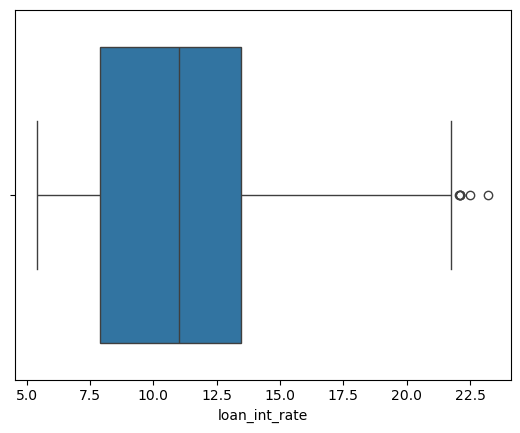

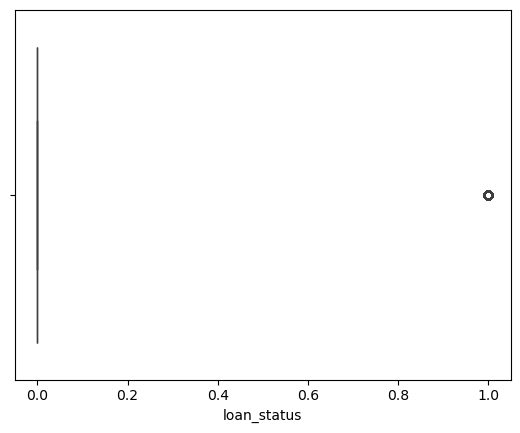

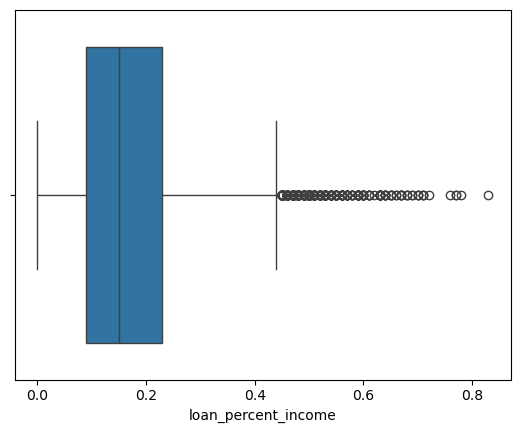

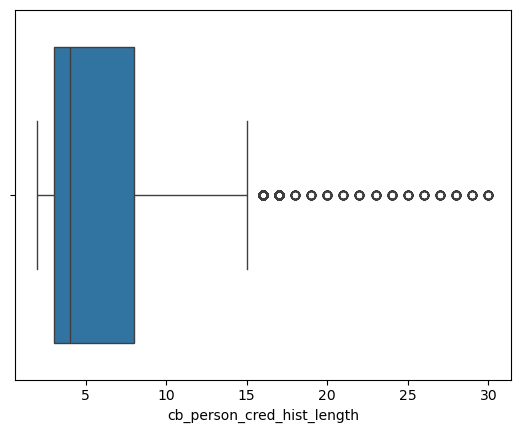

In [13]:
for i in numerical_cols:
  sns.boxplot(x = df[i])
  plt.show()

In [14]:
(df['person_age'] >100 ).sum()

np.int64(5)

In [15]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

<Axes: >

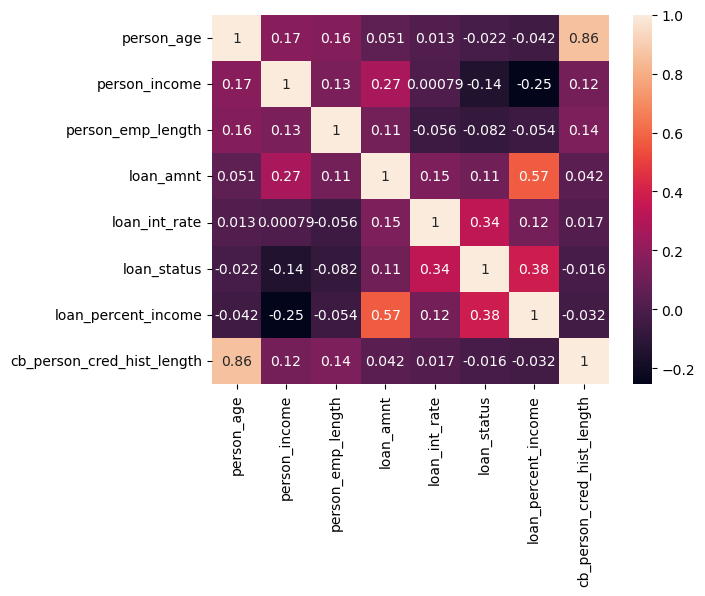

In [16]:
#checing correlation
sns.heatmap(df.corr(numeric_only = True), annot = True)

In [17]:
# Data Validation

In [18]:
df_copy = df.copy()
#Original rows
print(f"Orignial number of rows:{df_copy.shape[0]}")

Orignial number of rows:32581


In [19]:
#Remove Duplicate Rows
df_copy.drop_duplicates(inplace = True)
print(f"After removing duplicates: {df_copy.shape[0]}")

After removing duplicates: 32416


In [20]:
#removing ages below 18 and above 100 
df_copy = df_copy[(df_copy['person_age']>=18) & (df_copy['person_age'] <= 100)]


#removing employment length greater than age or extreme outliers
df_copy = df_copy[(df_copy['person_emp_length'] <= df_copy['person_age']) & (df_copy['person_emp_length'] <= 60)]


In [21]:
#Removing the rows with zero or negative income and loan amount
df_copy = df_copy[df_copy['loan_amnt'] > 0]

In [22]:
X = df_copy.drop("loan_status", axis = 1)
y = df_copy['loan_status']

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify = y)

In [24]:
df_copy.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [25]:
df_copy.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [26]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

In [27]:
#managing class imbalance - using class - weights
neg, pos = np.bincount(y_train)
scaled_weights = neg/pos #class weight

In [28]:
scaled_weights

np.float64(3.630344222758167)

In [29]:
#Cross-Validation for better testing and training
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
scoring = {'roc_auc': 'roc_auc', 'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}

In [49]:
#evalutor function
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve

def evaluate_model(model_name, model, X_test, y_test, threshold = None):
  
  y_pred_prob = model.predict_proba(X_test)[:,1]
  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  #metrices
  accuracy_s= accuracy_score(y_test, y_pred)
  precision_s = precision_score(y_test, y_pred)
  recall_s = recall_score(y_test, y_pred)
  f1_s = f1_score(y_test, y_pred)
  

  print(f"Accuracy: {accuracy_s:.2f}")
  print(f"Precision: {precision_s:.2f}")
  print(f"Recall: {recall_s:.2f}")
  print(f"F1: {f1_s:.2f}")
  print(f"Best Threshold: {threshold}")

  #confusion matrix
  cm = confusion_matrix(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)
  print(f"{model_name}: {class_report}")

  #Plotting confusion matrix
  sns.heatmap(cm, annot= True, fmt= 'd')
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()


  #Plotting ROC-AUC Curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(precisions, recalls)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()
  

In [31]:
#Logistic Regression: 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


preprocessor_lr = ColumnTransformer(
    transformers = [
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]) ,numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

In [32]:
#Logistic Regression Model
from sklearn.linear_model import LogisticRegression
lr_cv_pipleline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter = 1000, class_weight = 'balanced', random_state = 42))
])
lr_cv_pipleline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [33]:
#XGBOOST: Impute numeric only, impute + One- Hot encoding

preprocessor_xg = ColumnTransformer(
    transformers = [
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ]) ,numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

In [34]:
#XGBOOST Model
from xgboost import XGBClassifier

xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimators = 300, max_depth = 5, learning_rate = 0.1,
        scale_pos_weight = scaled_weights, random_state = 42
    ))
])
xgb_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [35]:
for cv_name, pipe in [('Logistic Regression', lr_cv_pipleline),
                      ('XGBoost', xgb_cv_pipeline)]:
                      cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs = -1)
                      print(cv_name)
                      print(f"ROC-AUC: {cv_results['test_roc_auc'].mean()}")
                      print(f"Accuracy: {cv_results['test_accuracy'].mean()}")
                      print(f"Precision: {cv_results['test_precision'].mean()}")
                      print(f"Recall: {cv_results['test_recall'].mean()}")
                      print(f"F1: {cv_results['test_f1'].mean()}")


Logistic Regression
ROC-AUC: 0.8713404164641778
Accuracy: 0.8110233618747266
Precision: 0.5436005160273509
Recall: 0.7792147057128033
F1: 0.6404194397951647
XGBoost
ROC-AUC: 0.9470834775851917
Accuracy: 0.9187462103272843
Precision: 0.822334499197852
Recall: 0.7960963471109318
F1: 0.8088818803731103


In [36]:
#Baseline Model
baseline_model = Pipeline([
    ('Preprocessor', preprocessor_lr),
    ("Classifier", LogisticRegression(class_weight='balanced'))
])
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('Classifier', LogisticRegression(class_weight='balanced'))])

Accuracy: 0.82
Precision: 0.55
Recall: 0.78
F1: 0.65
Baseline Logistic Model:               precision    recall  f1-score   support

           0       0.93      0.83      0.88      8157
           1       0.55      0.78      0.65      2246

    accuracy                           0.82     10403
   macro avg       0.74      0.80      0.76     10403
weighted avg       0.85      0.82      0.83     10403



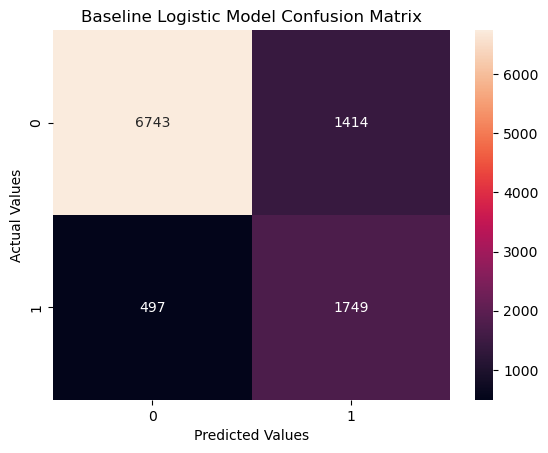

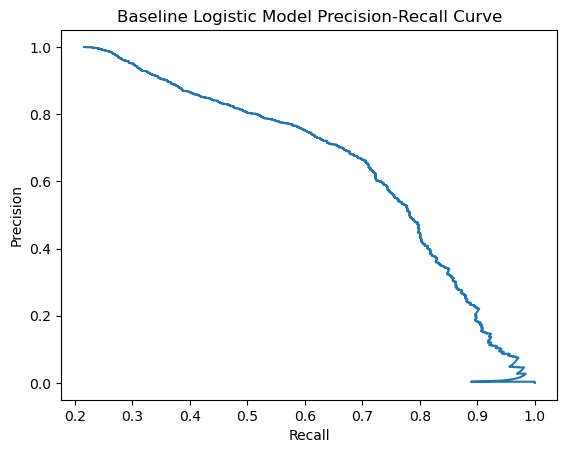

In [37]:
evaluate_model("Baseline Logistic Model", baseline_model, X_test, y_test)

In [38]:
#XGBoost model with hyperparameter tuning
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(scale_pos_weight = scaled_weights, random_state = 42, learning_rate = 0.1))
])
xg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [39]:
#hyperparamater tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth": randint(3,9),
    "classifier__learning_rate": uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6, 0.4), #Rows sampling
    "classifier__colsample_bytree": uniform(0.6, 0.4), #column sampling
    "classifier__min_child_weight": randint(1, 10),
    'classifier__gamma': uniform(0, 5)
}

random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter = 150,
    cv = cv,
    scoring = "average_precision",
    n_jobs = -1,
    verbose = 1
)

random_search.fit(X_train,y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'classifier__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x16c77d310>,
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x16c77d450>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x16c426f90>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x16c77d090>},
                   scoring='average_precision', verbose=1)

Accuracy: 0.92
Precision: 0.84
Recall: 0.79
F1: 0.81
Tuned XG model:               precision    recall  f1-score   support

           0       0.94      0.96      0.95      8157
           1       0.84      0.79      0.81      2246

    accuracy                           0.92     10403
   macro avg       0.89      0.87      0.88     10403
weighted avg       0.92      0.92      0.92     10403



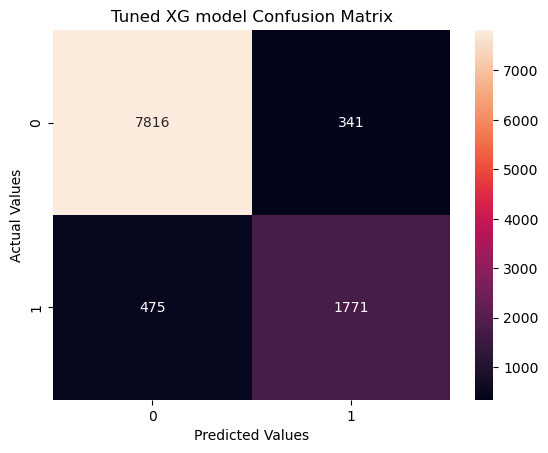

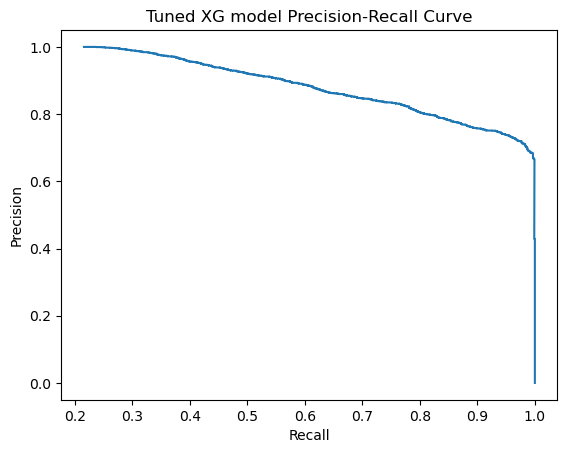

In [40]:
best_xg_model = random_search.best_estimator_

evaluate_model("Tuned XG model", best_xg_model, X_test, y_test)

In [41]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
preprocessor_rf = ColumnTransformer(
    transformers = [
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ]) ,numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

rf_model= Pipeline([

    ('preprocessor', preprocessor_rf),

    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ))

])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        n_estimators=300, random_state=42))])

Accuracy: 0.88
Precision: 0.71
Recall: 0.76
F1: 0.74
Random Forest:               precision    recall  f1-score   support

           0       0.93      0.91      0.92      8157
           1       0.71      0.76      0.74      2246

    accuracy                           0.88     10403
   macro avg       0.82      0.84      0.83     10403
weighted avg       0.89      0.88      0.88     10403



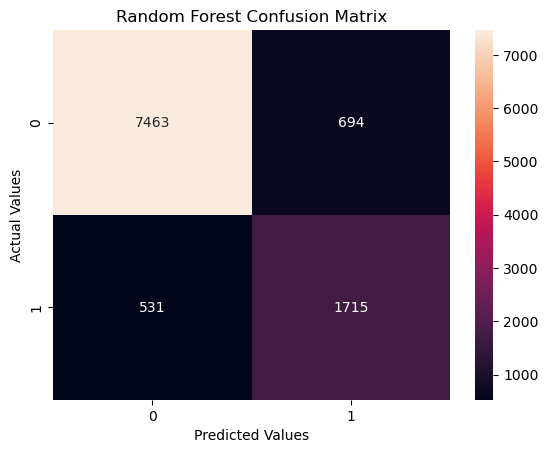

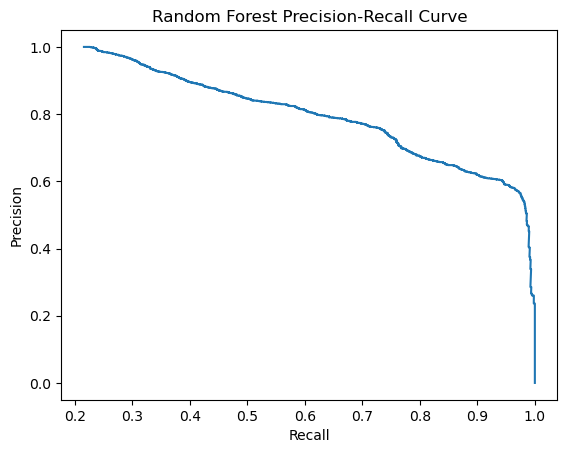

In [42]:
evaluate_model("Random Forest", rf_model, X_test, y_test)

In [43]:
param_grid_rf = {

    'classifier__n_estimators': randint(100, 600),

    'classifier__max_depth': randint(3, 15),

    'classifier__min_samples_split': randint(2, 20),

    'classifier__min_samples_leaf': randint(1, 10),

    'classifier__max_features': ['sqrt', 'log2', None],

    'classifier__class_weight': ['balanced', 'balanced_subsample']

}

In [44]:
rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid_rf,
    n_iter=100,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
rf_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'classifier__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x16c66c9e0>,
                                        'classifier__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x16c6c43b0>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x16c6436f0>},
                   random_state=42, scoring='average_precision', verbose=1)

In [45]:
print(rf_random_search.best_params_)

{'classifier__class_weight': 'balanced', 'classifier__max_depth': 14, 'classifier__max_features': None, 'classifier__min_samples_leaf': 3, 'classifier__min_samples_split': 18, 'classifier__n_estimators': 491}


In [46]:
best_rf_model = rf_random_search.best_estimator_

Accuracy: 0.93
Precision: 0.91
Recall: 0.73
F1: 0.81
Tuned Random Forest:               precision    recall  f1-score   support

           0       0.93      0.98      0.95      8157
           1       0.91      0.73      0.81      2246

    accuracy                           0.93     10403
   macro avg       0.92      0.86      0.88     10403
weighted avg       0.93      0.93      0.92     10403



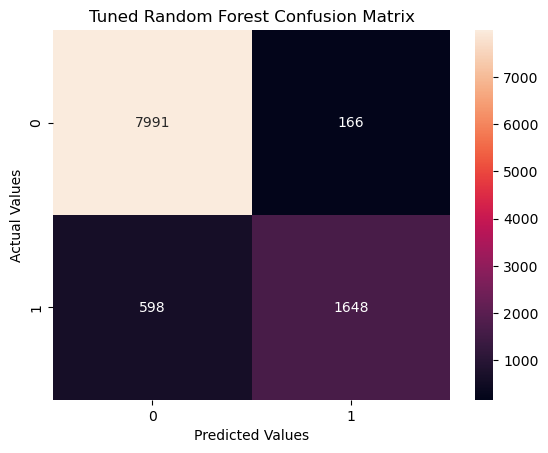

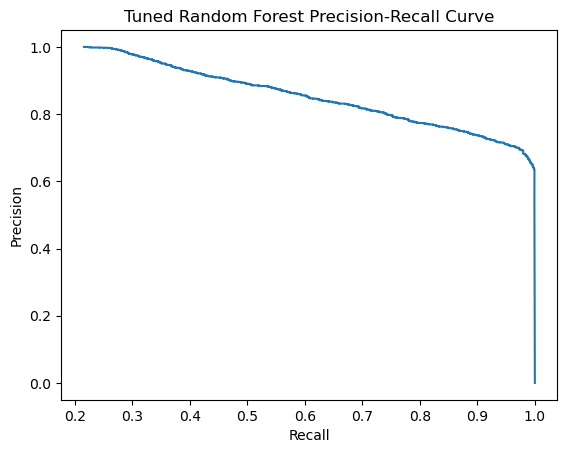

In [47]:
evaluate_model(
    "Tuned Random Forest",
    best_rf_model,
    X_test,
    y_test
)

Accuracy: 0.79
Precision: 1.00
Recall: 0.01
F1: 0.02
Best Threshold: 0.9997060894966125
XG Model with Threshold:               precision    recall  f1-score   support

           0       0.79      1.00      0.88      8157
           1       1.00      0.01      0.02      2246

    accuracy                           0.79     10403
   macro avg       0.89      0.51      0.45     10403
weighted avg       0.83      0.79      0.70     10403



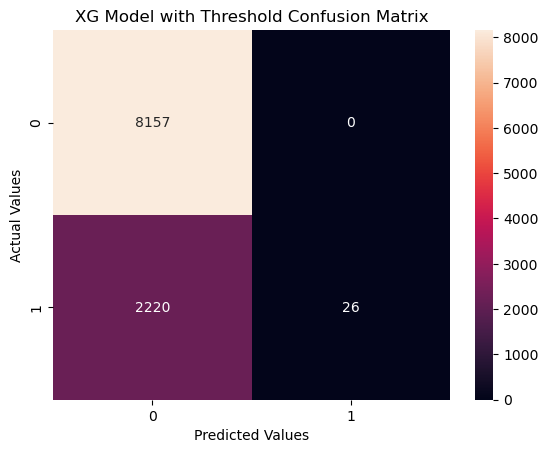

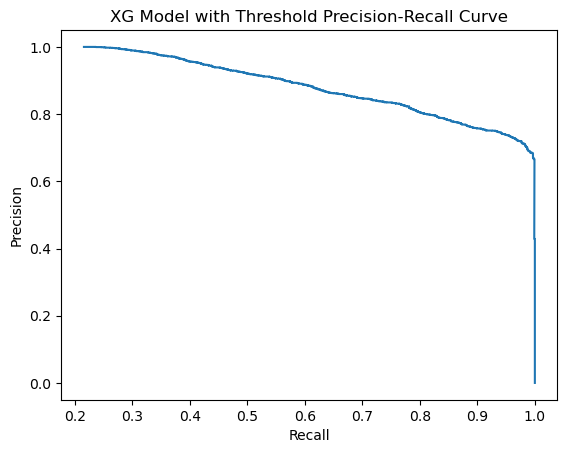

In [50]:
#threshold
prob = xg_model.predict_proba(X_test)[:,1]


precisions, recalls, thresholds = precision_recall_curve(y_test, prob)


f1 = 2 * (precisions - recalls) / (precisions + recalls + 1e-9)
f1

best = np.argmax(f1[:-1]) #highest values
best_threshold = thresholds[best]


evaluate_model("XG Model with Threshold", best_xg_model, X_test, y_test, best_threshold)

In [52]:
#Probability calibration
# 1. CAlibrated XGBoost Model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
calibrated_model = CalibratedClassifierCV(
    best_rf_model,
    method = 'sigmoid',
    cv = 5
)

calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(fill_value='Missing',
                                                                                                                  strategy='constant')),
                                                                                                   ('onehot',
                                                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                                                   ['person_home_ownership',
                                                                                    'loan_intent',
                                                                                    'loan_grade',
                                                                                    'cb_person_default_on_file'])])),
                                                 ('classifier',
                                                  RandomForestClassifier(class_weight='balanced',
                                                                         max_depth=14,
                                                                         max_features=None,
                                                                         min_samples_leaf=3,
                                                                         min_samples_split=18,
                                                                         n_estimators=491,
                                                                         random_state=42))]))

In [55]:
#2. Get probabilities
uncalibrated = best_rf_model.predict_proba(X_test)[:,1]
print(uncalibrated)
calibrated = calibrated_model.predict_proba(X_test)[:,1]
print(calibrated)

[0.04892479 0.07477982 0.36653527 ... 0.04990717 0.10870812 1.        ]
[0.02219315 0.02571601 0.17100554 ... 0.02147356 0.03581263 0.97222415]


In [56]:
#3. Create calibration curve
actual_uncal , predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins = 10)
actual_cal, predicted_cal = calibration_curve(y_test, calibrated, n_bins = 10)

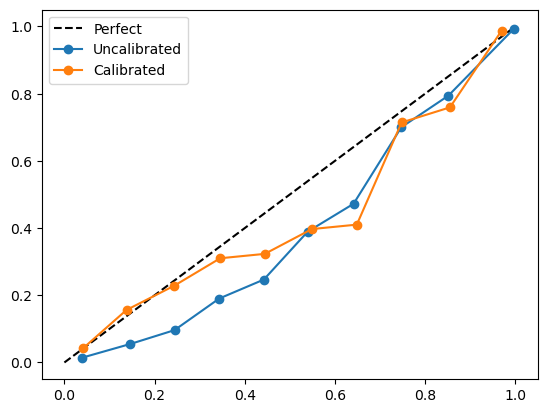

In [61]:
#4. Plot
plt.plot([0,1], [0,1], 'k--', label = "Perfect")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "Calibrated"
)

plt.legend()

In [74]:
#Shap Interpretation - Global & Local

import shap

In [68]:
#2. Get the trained model out of the pipeline
rf_classifier = best_rf_model.named_steps['classifier']


#3. Transform X_test using the same preprocessing used for training
X_test_transformed = best_rf_model.named_steps['preprocessor'].transform(X_test)


#4. Get features after one-hot encoding
features_names = best_rf_model.named_steps['preprocessor'].get_feature_names_out()

In [73]:
#5. Convert to a dataframe for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed, columns = features_names)


#6. Create SHAP explainer built for tree-based model
explainer = shap.TreeExplainer(rf_classifier)

In [76]:
#7. Calculate SHAP values for every row in the test set
shap_values = explainer.shap_values(X_test_df)


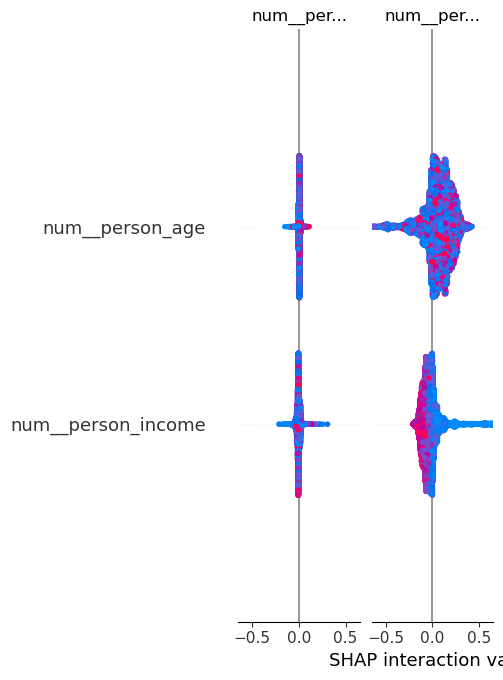

In [77]:
# Global explaination
shap.summary_plot(shap_values, X_test_df)

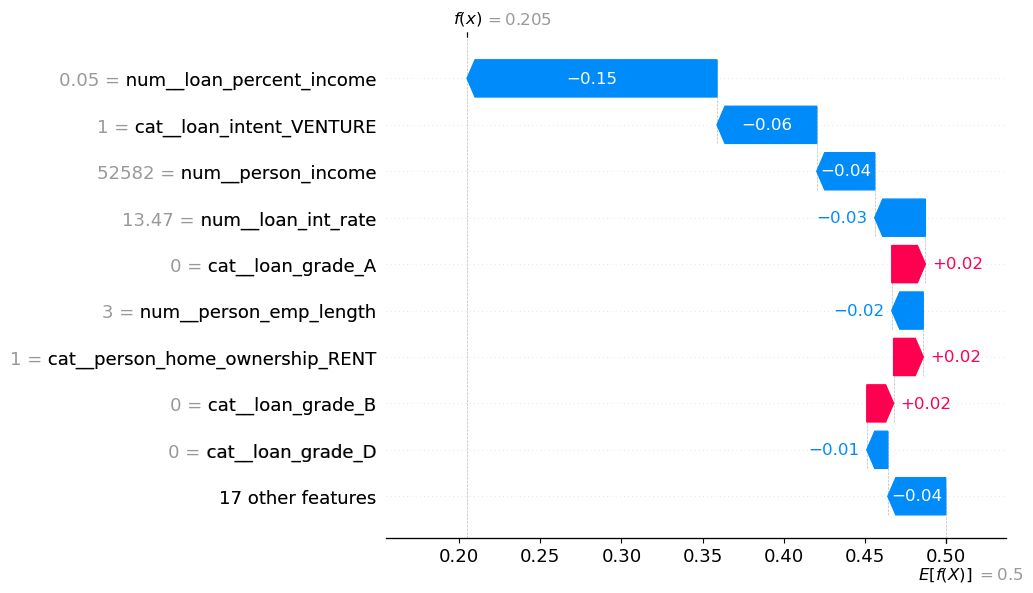

In [81]:
#Local explaination
row_index = 5

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[row_index, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test_df.iloc[row_index],
        feature_names=features_names
    )
)

In [82]:
#False Positive & False Negative
#Get predictions from best peforming model
y_pred= best_rf_model.predict(X_test)

In [83]:
#creating a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [84]:
#Identifing False Positive and False Negative
false_positive = result_df[(result_df['actual'] == 0) & (result_df['predicted'] == 1)]

false_negative = result_df[(result_df['actual'] == 1) & (result_df['predicted'] == 0)]

In [89]:
print(f"False Positive : {len(false_positive)}")
print(f"False Negative: {len(false_negative)}")

False Positive : 166
False Negative: 598


In [90]:
#False negative > False Positive 

In [91]:
# Saving model
import joblib

joblib.dump(calibrated_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [92]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']